In [13]:
pip install opencv-python


  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.


Image dimensions:  (256, 256, 3)


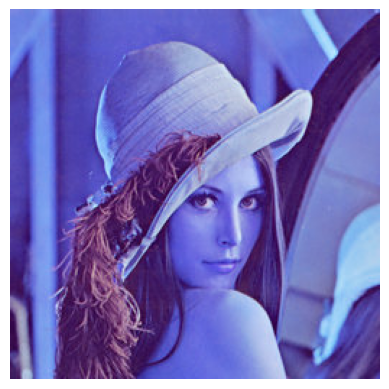

In [35]:
# READ AN IMAGE
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('Lena_RGB.png')
print('Image dimensions: ', np.shape(img))

plt.imshow(img, cmap='gray'),plt.axis('off')
plt.show()

In [20]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]

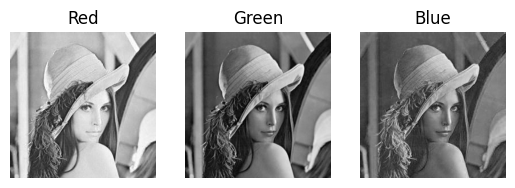

In [31]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red'),ax[0].axis('off')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green'),ax[1].axis('off')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue'),ax[2].axis('off')
plt.show()

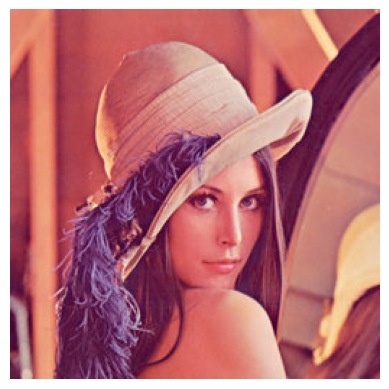

In [37]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray'),plt.axis("off")
plt.show()

### TRANSFORMACIONES DE INTENSIDAD

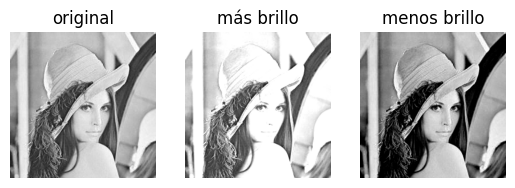

In [40]:
# CAMBIO DE BRILLO
img = cv2.imread('Lena_RGB.png')
img = img[:,:,2] # red color

mas_brillo = 50
menos_brillo = -100
mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de "+"
menos_brillo_img = cv2.add(img, menos_brillo)

fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original'), ax[0].axis('off')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo'), ax[1].axis('off')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo'), ax[2].axis('off')
plt.show()

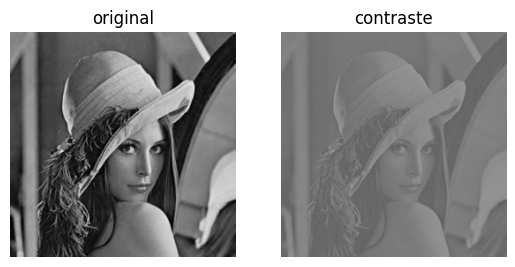

In [52]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('Lena_RGB.png')
img = img[:,:,1] # canal verde

contraste = -80

f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)

contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original'),ax[0].axis('off')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste'),ax[1].axis('off')
plt.show()

### CONVERSIONES DEL ESPACIO DE COLOR

C:\Users\alexi\AppData\Local\Temp\ipykernel_23036\3019843920.py:16: RuntimeWarning: invalid value encountered in cast
  CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')


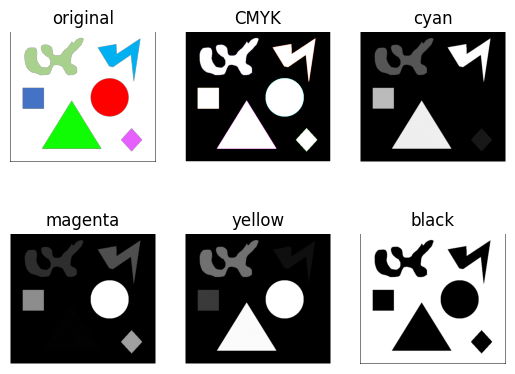

In [70]:
# RGB to CMYK
import numpy as np
from skimage import io

img = io.imread('figuras.png')
rgb = img.copy()
rgb_p = rgb.astype('uint8')/255

with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    # Extrae los canales de acuerdo con la ecuación del power point
    C = (1 - rgb_p[:,:,0] - K) / (1 - K)
    M = (1 - rgb_p[:,:,1] - K) / (1 - K)
    Y = (1 - rgb_p[:,:,2] - K) / (1 - K)

CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
C,M,Y,K = cv2.split(CMYK)

fig, ax = plt.subplots(2,3)
ax[0,0].imshow(img, cmap='gray'), ax[0,0].set_title('original'),ax[0,0].axis('off')
ax[0,1].imshow(CMYK.astype('uint8'), cmap='gray'), ax[0,1].set_title('CMYK'),ax[0,1].axis('off')
ax[0,2].imshow(C.astype('uint8'), cmap='gray'), ax[0,2].set_title('cyan'),ax[0,2].axis('off')
ax[1,0].imshow(M.astype('uint8'), cmap='gray'), ax[1,0].set_title('magenta'),ax[1,0].axis('off')
ax[1,1].imshow(Y.astype('uint8'), cmap='gray'), ax[1,1].set_title('yellow'),ax[1,1].axis('off')
ax[1,2].imshow(K.astype('uint8'), cmap='gray'), ax[1,2].set_title('black'),ax[1,2].axis('off')
plt.show()

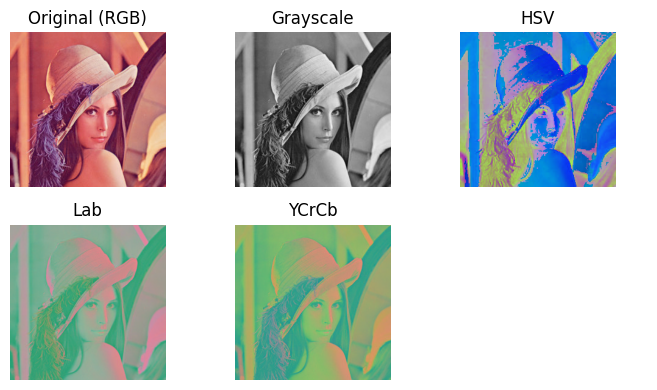

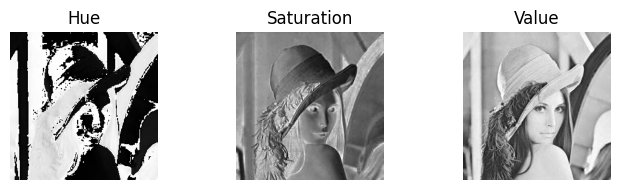

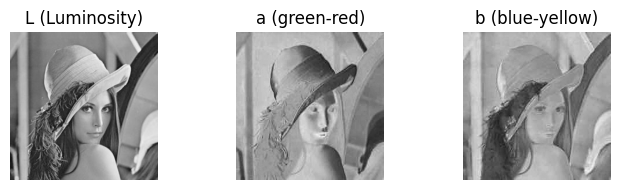

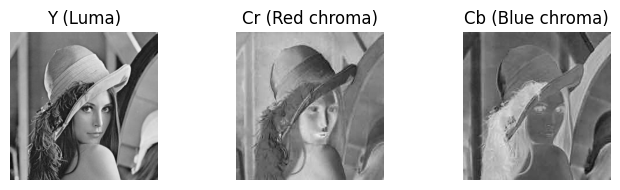

In [76]:
# Otras conversiones

img = cv2.imread('Lena_RGB.png')

# Convert color spaces
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # gray-scale
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # RGB for proper display
HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)        # (H)ue, (S)aturation and (V)alue
Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)        # (L)uminosidad, a-b colores complementarios
YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)    # Y-Luma, Cr-Cb crominancia rojo y azul

# Display all conversions
fig, ax = plt.subplots(2, 3, figsize=(7, 4))

# Row 1: Original, Grayscale, HSV
ax[0,0].imshow(RGB_img)
ax[0,0].set_title('Original (RGB)')
ax[0,0].axis('off')

ax[0,1].imshow(gray_img, cmap='gray')
ax[0,1].set_title('Grayscale')
ax[0,1].axis('off')

ax[0,2].imshow(HSV)
ax[0,2].set_title('HSV')
ax[0,2].axis('off')

# Row 2: Lab, YCrCb
ax[1,0].imshow(Lab)
ax[1,0].set_title('Lab')
ax[1,0].axis('off')

ax[1,1].imshow(YCrCb)
ax[1,1].set_title('YCrCb')
ax[1,1].axis('off')

ax[1,2].axis('off')  # Hide empty subplot

plt.tight_layout()
plt.show()

# Display individual channels for HSV
H, S, V = cv2.split(HSV)
fig, ax = plt.subplots(1, 3, figsize=(7, 2))
ax[0].imshow(H, cmap='gray'), ax[0].set_title('Hue'), ax[0].axis('off')
ax[1].imshow(S, cmap='gray'), ax[1].set_title('Saturation'), ax[1].axis('off')
ax[2].imshow(V, cmap='gray'), ax[2].set_title('Value'), ax[2].axis('off')
plt.tight_layout()
plt.show()

# Display individual channels for Lab
L, a, b = cv2.split(Lab)
fig, ax = plt.subplots(1, 3, figsize=(7, 2))
ax[0].imshow(L, cmap='gray'), ax[0].set_title('L (Luminosity)'), ax[0].axis('off')
ax[1].imshow(a, cmap='gray'), ax[1].set_title('a (green-red)'), ax[1].axis('off')
ax[2].imshow(b, cmap='gray'), ax[2].set_title('b (blue-yellow)'), ax[2].axis('off')
plt.tight_layout()
plt.show()

# Display individual channels for YCrCb
Y, Cr, Cb = cv2.split(YCrCb)
fig, ax = plt.subplots(1, 3, figsize=(7, 2))
ax[0].imshow(Y, cmap='gray'), ax[0].set_title('Y (Luma)'), ax[0].axis('off')
ax[1].imshow(Cr, cmap='gray'), ax[1].set_title('Cr (Red chroma)'), ax[1].axis('off')
ax[2].imshow(Cb, cmap='gray'), ax[2].set_title('Cb (Blue chroma)'), ax[2].axis('off')
plt.tight_layout()
plt.show()



### TRANSFORMACIONES GEOMÉTRICAS

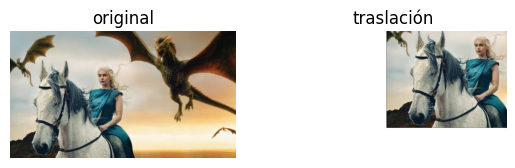

In [85]:
# TRASLACIÓN
img = io.imread('GOT.png')
rows, cols, ch = img.shape
 
M = np.float32([[1,0,280],[0,1,-80]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original'),ax[0].axis('off')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación'),ax[1].axis('off')
plt.show()

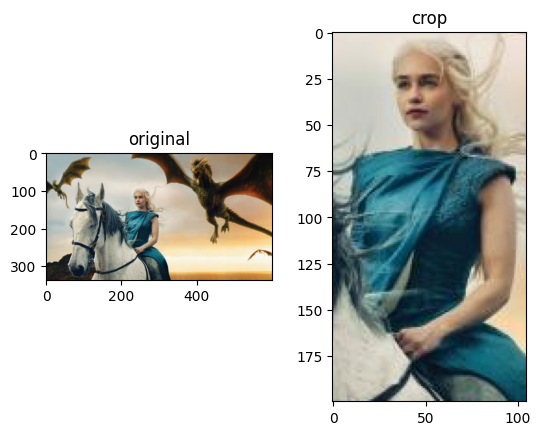

In [87]:
# CROPPING
img = io.imread('GOT.png')

new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

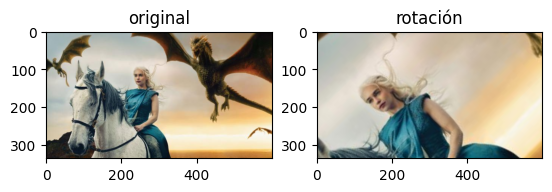

In [89]:
# ROTACIÓN
img = io.imread('GOT.png')
rows, cols, ch = img.shape

M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=45,scale=2) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()

In [ ]:
# PERSPECTIVA
img = cv2.imread('images/sudoku.png')
rows, cols, ch = img.shape
 
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)
plt.title('Keypoints para perspectiva')
plt.show()
 
M = cv2.getPerspectiveTransform(pts1,pts2) # Defino la matriz de transformación
pers = cv2.warpPerspective(img,M,(305,305)) # Aplico la transformación
crop =  img[50:400,20:400]

figs, ax = plt.subplots(1,2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()


In [ ]:
# FLIPPING

# Leer la imagen "Lena_RGB.png" en formato RGB
img = ???

# Voltear la imagen para conseguir las siguientes transformaciones. Utiliza el método "cv2.flip()"
  
flipVertical = ???
flipHorizontal = ???
flipBoth = ???
 
figs, ax = plt.subplots(1,4)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(flipVertical, cmap='gray'), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal, cmap='gray'), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth, cmap='gray'), ax[3].set_title('flip ambos')
plt.show()